# Phase 2C: candidate reconfiguration-episode diagnostics

## Purpose

This notebook asks whether simple changes inside the **separate typed relational channels** can support a descriptive candidate interval of defensive reconfiguration. An “episode” means only a visually defensible temporal interval. It is not a tactical event, state, responsibility transfer, assignment, success/failure judgment, or causal mechanism.

The exact seven Phase 2B windows and frozen relationship selections are reused. No examples are added or replaced after inspecting the interval logic.

## Fixed illustrative interval choices

Rates use the established centered 7-frame rolling mean and centered finite difference. Fixed 5/7/9-frame sensitivity is retained. A same-direction run must last at least **0.6 s** to be displayed as persistent. This duration is an illustrative, non-optimized diagnostic choice intended only to reject isolated derivative spikes. No magnitude threshold is imposed.

Two interval lenses are examined:

1. **Direction-agnostic typed activity overlap:** persistent focal collective-relative movement overlaps persistent defender–defender and defender–opponent change. This tests overcalling: soccer may satisfy it simply because many relationships are always moving.
2. **Interior-compression overlap:** at least two already-displayed defender pairs and at least two already-displayed defender–opponent distances contract persistently together. “Two” is an illustrative, non-optimized logical choice for multi-defender convergence, not a universal threshold or score. It is intentionally specific and cannot define all forms of reconfiguration.

The identities and directions of contributing relationships remain visible. Nothing is summed into a magnitude or weighted across channels.

In [1]:
from pathlib import Path
import hashlib,itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
LENGTH,WIDTH,FPS=105.,68.,25.; MIN_DURATION=0.6

def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
display(pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]}))

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3); ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ids: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids
home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Exact fixed Phase 2B cases

In [3]:
CASES=[
 {'name':'coordinated collective movement','period':1,'start':1888.0,'end':1896.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':None,'selected_defs':None,'secondary_opponents':[]},
 {'name':'apparent individual excursion','period':1,'start':590.0,'end':598.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':'23','selected_defs':None,'secondary_opponents':[]},
 {'name':'tackle / engagement','period':1,'start':550.76,'end':555.76,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'9','selected_defs':None,'secondary_opponents':[]},
 {'name':'primary interior-threat anchor','period':1,'start':1228.12,'end':1232.12,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'secondary_opponents':['6','7','5'],'anchor':1230.12},
 {'name':'collective accommodation / engagement','period':1,'start':1229.28,'end':1234.28,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'secondary_opponents':['6','7','5'],'anchor':1232.28},
 {'name':'collective-translation contrast','period':2,'start':3679.88,'end':3684.88,'def_team':'Home','focal':'8','opp_team':'Away','opponent':'15','selected_defs':None,'secondary_opponents':[],'anchor':3682.88},
 {'name':'negative interior-threat case','period':2,'start':4195.04,'end':4199.04,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'10','selected_defs':['16','18','21'],'secondary_opponents':['12','6','3'],'anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','period','start','end','def_team','focal','opp_team','opponent']])

,name,period,start,end,def_team,focal,opp_team,opponent
0,coordinated collective movement,1,1888.00,1896.00,Home,2,Away,None
1,apparent individual excursion,1,590.00,598.00,Home,2,Away,23
2,tackle / engagement,1,550.76,555.76,Away,16,Home,9
3,primary interior-threat anchor,1,1228.12,1232.12,Away,19,Home,10
4,collective accommodation / engagement,1,1229.28,1234.28,Away,19,Home,10
5,collective-translation contrast,2,3679.88,3684.88,Home,8,Away,15
6,negative interior-threat case,2,4195.04,4199.04,Away,16,Home,10


In [4]:
def case_window(case):
    d=tracking[case['def_team']]; o=tracking[case['opp_team']]
    w=d[(d.Period==case['period'])&d['Time [s]'].between(case['start'],case['end'])].copy()
    cols=['Frame']+[f"{case['opp_team']}_{p}_{a}" for p in players[case['opp_team']] for a in ('x','y')]
    return w.merge(o[cols],on='Frame',validate='one_to_one')
def outfield(case): return [p for p in players[case['def_team']] if p!=goalkeeper[case['def_team']]]
def xy(r,team,p): return np.array([r[f'{team}_{p}_x']*LENGTH,r[f'{team}_{p}_y']*WIDTH],float)
def nearest_ids(case,w,count=3):
    if case['selected_defs']: return case['selected_defs']
    r=w.iloc[0]; f=xy(r,case['def_team'],case['focal']); vals=[]
    for p in outfield(case):
        if p==case['focal']: continue
        q=xy(r,case['def_team'],p)
        if np.isfinite(q).all(): vals.append((np.linalg.norm(q-f),p))
    return [case['focal']]+[p for _,p in sorted(vals)[:count-1]]
def add_base(case):
    w=case_window(case); dt=case['def_team']; ids=outfield(case); refs=[p for p in ids if p!=case['focal']]
    w['centroid_x_m']=w[[f'{dt}_{p}_x' for p in ids]].mean(axis=1)*LENGTH; w['centroid_y_m']=w[[f'{dt}_{p}_y' for p in ids]].mean(axis=1)*WIDTH
    w['loo_x_m']=w[[f'{dt}_{p}_x' for p in refs]].mean(axis=1)*LENGTH; w['loo_y_m']=w[[f'{dt}_{p}_y' for p in refs]].mean(axis=1)*WIDTH
    w['focal_loo_x_m']=w[f'{dt}_{case["focal"]}_x']*LENGTH-w.loo_x_m; w['focal_loo_y_m']=w[f'{dt}_{case["focal"]}_y']*WIDTH-w.loo_y_m
    w['plot_t']=w['Time [s]']-(case.get('anchor') if case.get('anchor') is not None else case['start'])
    return w
def smooth_rate(values,time,window=7):
    s=pd.Series(values,index=time.index).rolling(window,center=True,min_periods=window).mean()
    return s,(s.shift(-1)-s.shift(1))/(time.shift(-1)-time.shift(1))
for case in CASES:
    w=add_base(case); case['display_defs']=nearest_ids(case,w)
    print(case['name'],case['display_defs'])

coordinated collective movement ['2', '3', '7']
apparent individual excursion ['2', '3', '1']
tackle / engagement ['16', '17', '15']
primary interior-threat anchor ['19', '20', '21']
collective accommodation / engagement ['19', '20', '21']
collective-translation contrast ['8', '10', '5']
negative interior-threat case ['16', '18', '21']


## Transparent interval construction

The helper below converts sustained positive or negative smoothed-rate runs into intervals. It does not evaluate tactical meaning. A persistent contraction may be ordinary continuous play; a persistent expansion may be appropriate coverage. Relationship identity and sign must be interpreted against pitch geometry.

In [5]:
def persistent_mask(rate,time,direction='either',min_duration=MIN_DURATION):
    valid=rate.notna()
    sign=pd.Series(np.where(rate>0,1,np.where(rate<0,-1,0)),index=rate.index)
    groups=(sign.ne(sign.shift())|~valid|~valid.shift(fill_value=False)).cumsum()
    keep=pd.Series(False,index=rate.index)
    wanted={-1,1} if direction=='either' else ({-1} if direction=='contract' else {1})
    for _,idx in rate[valid].groupby(groups[valid]).groups.items():
        idx=list(idx); duration=time.loc[idx[-1]]-time.loc[idx[0]]
        if sign.loc[idx[0]] in wanted and duration>=min_duration: keep.loc[idx]=True
    return keep
def mask_intervals(mask,time,relative_to):
    groups=(mask.ne(mask.shift())).cumsum(); out=[]
    for _,idx in mask[mask].groupby(groups[mask]).groups.items():
        idx=list(idx); out.append((time.loc[idx[0]]-relative_to,time.loc[idx[-1]]-relative_to))
    return out
def relation_sets(case,window=7):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']; time=w['Time [s]']
    levels={'dd':{},'do':{},'secondary':{},'loo':{'focal LOO x':w.focal_loo_x_m,'focal LOO y':w.focal_loo_y_m},'ball':{}}
    for p,q in itertools.combinations(defs,2): levels['dd'][f'{p}–{q}']=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH)
    if case['opponent']:
        for p in defs: levels['do'][f'{p}–{case["opponent"]}']=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH)
        for p,a in zip(defs,case['secondary_opponents']): levels['secondary'][f'{p}–{a}']=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{a}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{a}_y'])*WIDTH)
    bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    levels['ball']={'focal–ball x':w[f'{dt}_{case["focal"]}_x']*LENGTH-bx,'focal–ball y':w[f'{dt}_{case["focal"]}_y']*WIDTH-by}
    rates={ch:{name:smooth_rate(v,time,window)[1] for name,v in vals.items()} for ch,vals in levels.items()}
    return w,levels,rates
def union_persistent(rates,time,direction='either'):
    mask=pd.Series(False,index=time.index)
    for rate in rates.values(): mask |= persistent_mask(rate,time,direction)
    return mask
def at_least_persistent(rates,time,direction,n):
    masks=[persistent_mask(rate,time,direction).astype(int) for rate in rates.values()]
    return sum(masks)>=n if masks else pd.Series(False,index=time.index)
def retain_interval_runs(mask,time,min_duration=MIN_DURATION):
    groups=(mask.ne(mask.shift())).cumsum(); keep=pd.Series(False,index=mask.index)
    for _,idx in mask[mask].groupby(groups[mask]).groups.items():
        idx=list(idx)
        if time.loc[idx[-1]]-time.loc[idx[0]]>=min_duration: keep.loc[idx]=True
    return keep
def candidate_masks(case,window=7):
    w,levels,rates=relation_sets(case,window); time=w['Time [s]']
    typed_activity=union_persistent(rates['loo'],time)&union_persistent(rates['dd'],time)&union_persistent(rates['do'],time)
    compression=at_least_persistent(rates['dd'],time,'contract',2)&at_least_persistent(rates['do'],time,'contract',2)
    return w,levels,rates,retain_interval_runs(typed_activity,time),retain_interval_runs(compression,time)

## Primary 1230.12 s worked example

The lane plot shows every contributing relationship separately. Shading indicates only the fixed interior-compression overlap; it does not claim a detected event.

direction-agnostic typed activity intervals: [(np.float64(-1.8399999999999181), np.float64(1.8400000000001455))]
interior-compression overlap intervals: [(np.float64(-1.199999999999818), np.float64(1.8400000000001455))]


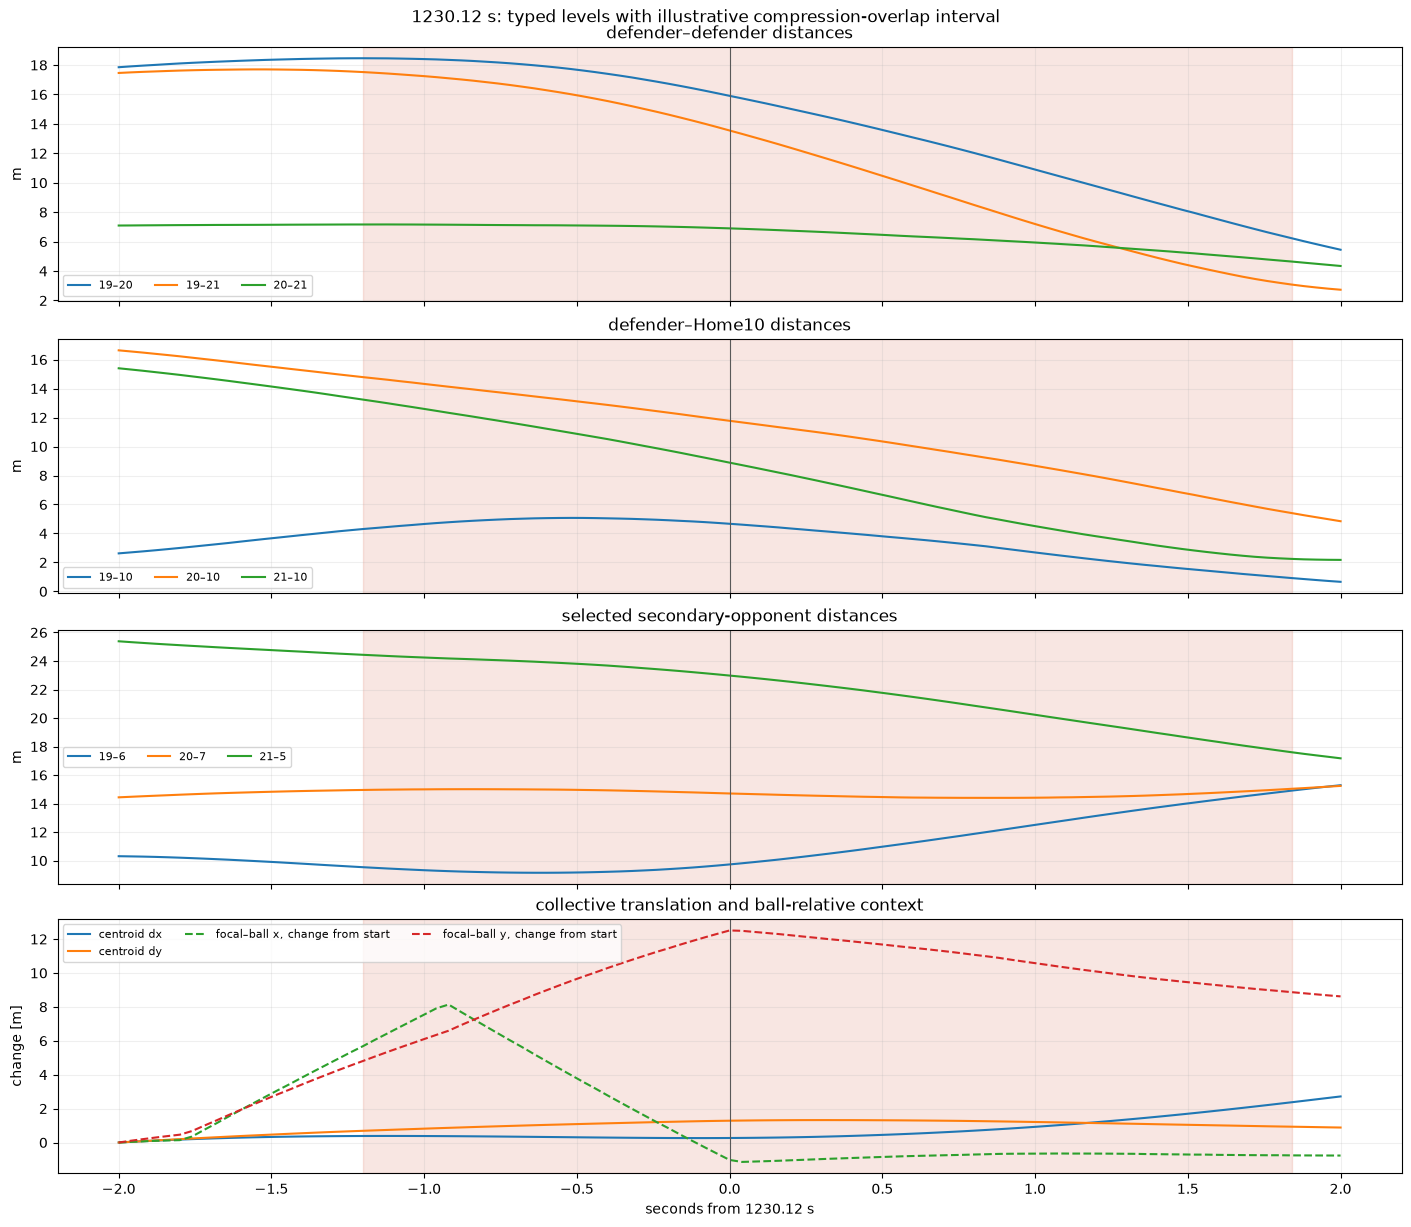

In [6]:
PRIMARY=next(x for x in CASES if x['name']=='primary interior-threat anchor')
w,levels,rates,activity,compression=candidate_masks(PRIMARY,7); time=w['Time [s]']; t=w['plot_t']
print('direction-agnostic typed activity intervals:',mask_intervals(activity,time,PRIMARY['anchor']))
print('interior-compression overlap intervals:',mask_intervals(compression,time,PRIMARY['anchor']))

fig,axes=plt.subplots(4,1,figsize=(14,12),sharex=True,constrained_layout=True)
for name,v in levels['dd'].items(): axes[0].plot(t,v,label=name)
axes[0].set(title='defender–defender distances',ylabel='m')
for name,v in levels['do'].items(): axes[1].plot(t,v,label=name)
axes[1].set(title='defender–Home10 distances',ylabel='m')
for name,v in levels['secondary'].items(): axes[2].plot(t,v,label=name)
axes[2].set(title='selected secondary-opponent distances',ylabel='m')
axes[3].plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],label='centroid dx'); axes[3].plot(t,w.centroid_y_m-w.centroid_y_m.iloc[0],label='centroid dy')
for name,v in levels['ball'].items(): axes[3].plot(t,v-v.iloc[0],ls='--',label=f'{name}, change from start')
axes[3].set(title='collective translation and ball-relative context',ylabel='change [m]',xlabel='seconds from 1230.12 s')
for ax in axes:
    ax.axvline(0,c='0.35',lw=.8); ax.grid(alpha=.2); ax.legend(fontsize=8,ncol=3)
    ax.fill_between(t,0,1,where=compression,transform=ax.get_xaxis_transform(),color='#cc3311',alpha=.12,label='_nolegend_')
fig.suptitle('1230.12 s: typed levels with illustrative compression-overlap interval',y=1.01); plt.show()

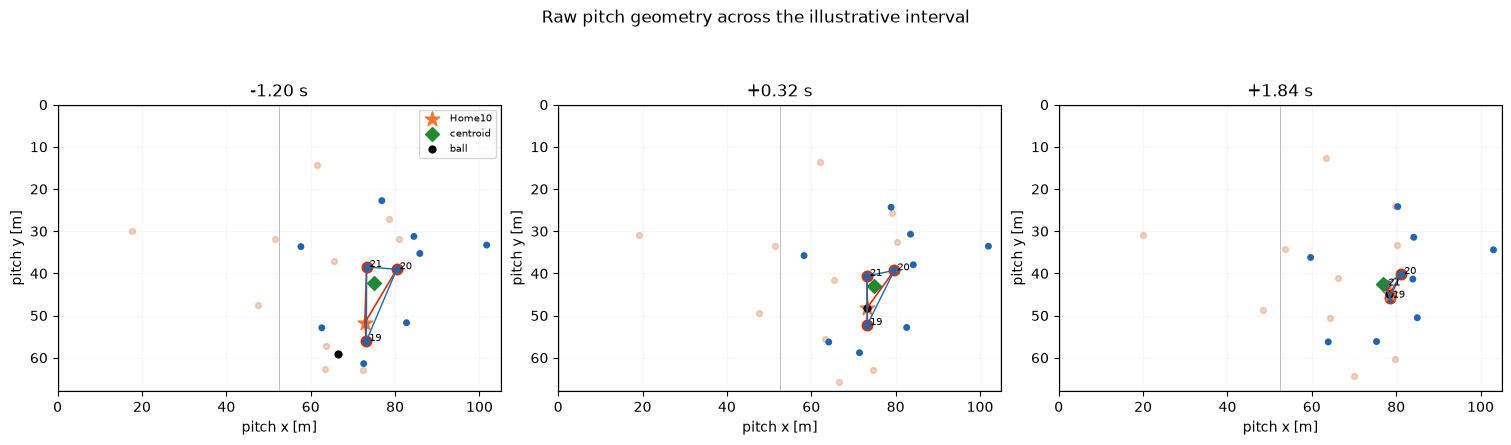

In [7]:
def pitch(ax):
    ax.plot([0,LENGTH,LENGTH,0,0],[0,0,WIDTH,WIDTH,0],c='0.35',lw=1); ax.axvline(LENGTH/2,c='0.75',lw=.7)
    ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',xlabel='pitch x [m]',ylabel='pitch y [m]'); ax.grid(alpha=.1)
def nearest_row(w,target): return w.loc[(w['Time [s]']-target).abs().idxmin()]
def interval_snapshots(case,mask):
    w=add_base(case); ints=mask_intervals(mask,w['Time [s]'],case['anchor'])
    if not ints: print('No compression-overlap interval'); return
    a,b=max(ints,key=lambda z:z[1]-z[0]); moments=[a,(a+b)/2,b]; dt,ot=case['def_team'],case['opp_team']
    fig,axes=plt.subplots(1,3,figsize=(15,4.5),constrained_layout=True)
    for ax,off in zip(axes,moments):
        r=nearest_row(w,case['anchor']+off); pitch(ax)
        for p in players[ot]: ax.scatter(*xy(r,ot,p),c='#dd9977',s=18,alpha=.45)
        for p in players[dt]:
            emph=p in case['display_defs']; ax.scatter(*xy(r,dt,p),c='#2266aa',s=52 if emph else 25,edgecolor='#cc3311' if emph else 'none',linewidth=1.4)
            if emph: ax.text(*xy(r,dt,p),f' {p}',fontsize=7)
        threat=xy(r,ot,case['opponent']); ax.scatter(*threat,c='#ee7733',marker='*',s=120,label='Home10')
        for p in case['display_defs']:
            d=xy(r,dt,p); ax.plot([d[0],threat[0]],[d[1],threat[1]],c='#cc3311',lw=1.2)
        for p,q in itertools.combinations(case['display_defs'],2):
            x1,x2=xy(r,dt,p),xy(r,dt,q); ax.plot([x1[0],x2[0]],[x1[1],x2[1]],c='#2266aa',lw=1)
        ax.scatter(r.centroid_x_m,r.centroid_y_m,c='#228833',marker='D',s=50,label='centroid'); ax.scatter(r[f'{dt}_ball_x']*LENGTH,r[f'{dt}_ball_y']*WIDTH,c='black',s=24,label='ball'); ax.set_title(f'{off:+.2f} s')
    axes[0].legend(fontsize=7); fig.suptitle('Raw pitch geometry across the illustrative interval',y=1.03); plt.show()
interval_snapshots(PRIMARY,compression)

In [8]:
def interval_change_table(case,mask):
    w,levels,rates,_,_=candidate_masks(case,7); ints=mask_intervals(mask,w['Time [s]'],case['anchor'])
    if not ints: return pd.DataFrame()
    a,b=max(ints,key=lambda z:z[1]-z[0]); start=nearest_row(w,case['anchor']+a); end=nearest_row(w,case['anchor']+b); rows=[]
    for channel in ['dd','do','secondary']:
        for name,v in levels[channel].items(): rows.append({'channel':channel,'relationship':name,'start_m':v.loc[start.name],'end_m':v.loc[end.name],'change_m':v.loc[end.name]-v.loc[start.name]})
    rows += [{'channel':'collective','relationship':'centroid x','start_m':w.centroid_x_m.loc[start.name],'end_m':w.centroid_x_m.loc[end.name],'change_m':w.centroid_x_m.loc[end.name]-w.centroid_x_m.loc[start.name]},
             {'channel':'collective','relationship':'centroid y','start_m':w.centroid_y_m.loc[start.name],'end_m':w.centroid_y_m.loc[end.name],'change_m':w.centroid_y_m.loc[end.name]-w.centroid_y_m.loc[start.name]}]
    return pd.DataFrame(rows),a,b
primary_changes,a,b=interval_change_table(PRIMARY,compression)
print(f'longest illustrative interval: {a:+.2f} to {b:+.2f} s relative to anchor ({b-a:.2f} s)')
display(primary_changes.round(3))

longest illustrative interval: -1.20 to +1.84 s relative to anchor (3.04 s)


,channel,relationship,start_m,end_m,change_m
0,dd,19–20,18.462,6.230,-12.232
1,dd,19–21,17.522,3.082,-14.441
2,dd,20–21,7.165,4.646,-2.518
3,do,19–10,4.307,0.922,-3.385
4,do,20–10,14.788,5.408,-9.380
5,do,21–10,13.237,2.245,-10.992
6,secondary,19–6,9.537,14.908,5.371
7,secondary,20–7,14.955,15.037,0.082
8,secondary,21–5,24.433,17.600,-6.833
9,collective,centroid x,74.958,76.948,1.990


### Primary-case interpretation

The compression-overlap interval is a visually defensible candidate because multiple preselected defender pairs and multiple defender–Home10 distances contract persistently together, while raw snapshots show the same convergence. The relationship-level table retains which pairs changed and shows secondary relationships moving differently. Centroid and ball-relative traces remain visible rather than being subtracted into a score.

This interval is not uniquely determined. Its edges come from the illustrative 0.6 s persistence rule and the non-optimized “two plus two” overlap. It describes one interior-compression pattern, not all defensive reconfiguration. The direction-agnostic activity overlap is broader and less selective, demonstrating why “many things are moving” is not enough.

## Cross-case adversarial comparison

The table applies the same fixed logic to every case. `n/a` means the source diagnostic fixed no opponent pair, so the logic cannot be evaluated rather than silently inventing one.

In [9]:
def fmt_intervals(vals):
    return '; '.join(f'{a:+.2f}…{b:+.2f}' for a,b in vals) if vals else 'none'
rows=[]
for case in CASES:
    for window in [5,7,9]:
        w,levels,rates,activity,compression=candidate_masks(case,window); ref=case.get('anchor') if case.get('anchor') is not None else case['start']
        rows.append({'case':case['name'],'smooth_frames':window,
                     'typed_activity_overlap':('n/a' if not levels['do'] else fmt_intervals(mask_intervals(activity,w['Time [s]'],ref))),
                     'interior_compression_overlap':('n/a' if not levels['do'] else fmt_intervals(mask_intervals(compression,w['Time [s]'],ref)))})
comparison=pd.DataFrame(rows)
display(comparison)

,case,smooth_frames,typed_activity_overlap,interior_compression_overlap
0,coordinated collective movement,5,n/a,n/a
1,coordinated collective movement,7,n/a,n/a
2,coordinated collective movement,9,n/a,n/a
3,apparent individual excursion,5,+0.12…+7.88,none
4,apparent individual excursion,7,+0.16…+7.84,none
5,apparent individual excursion,9,+0.20…+7.80,none
6,tackle / engagement,5,+0.12…+4.88,+0.12…+1.52
7,tackle / engagement,7,+0.16…+4.84,+0.16…+1.52
8,tackle / engagement,9,+0.20…+4.80,+0.20…+1.52
9,primary interior-threat anchor,5,-1.88…+1.88,-1.20…+1.88


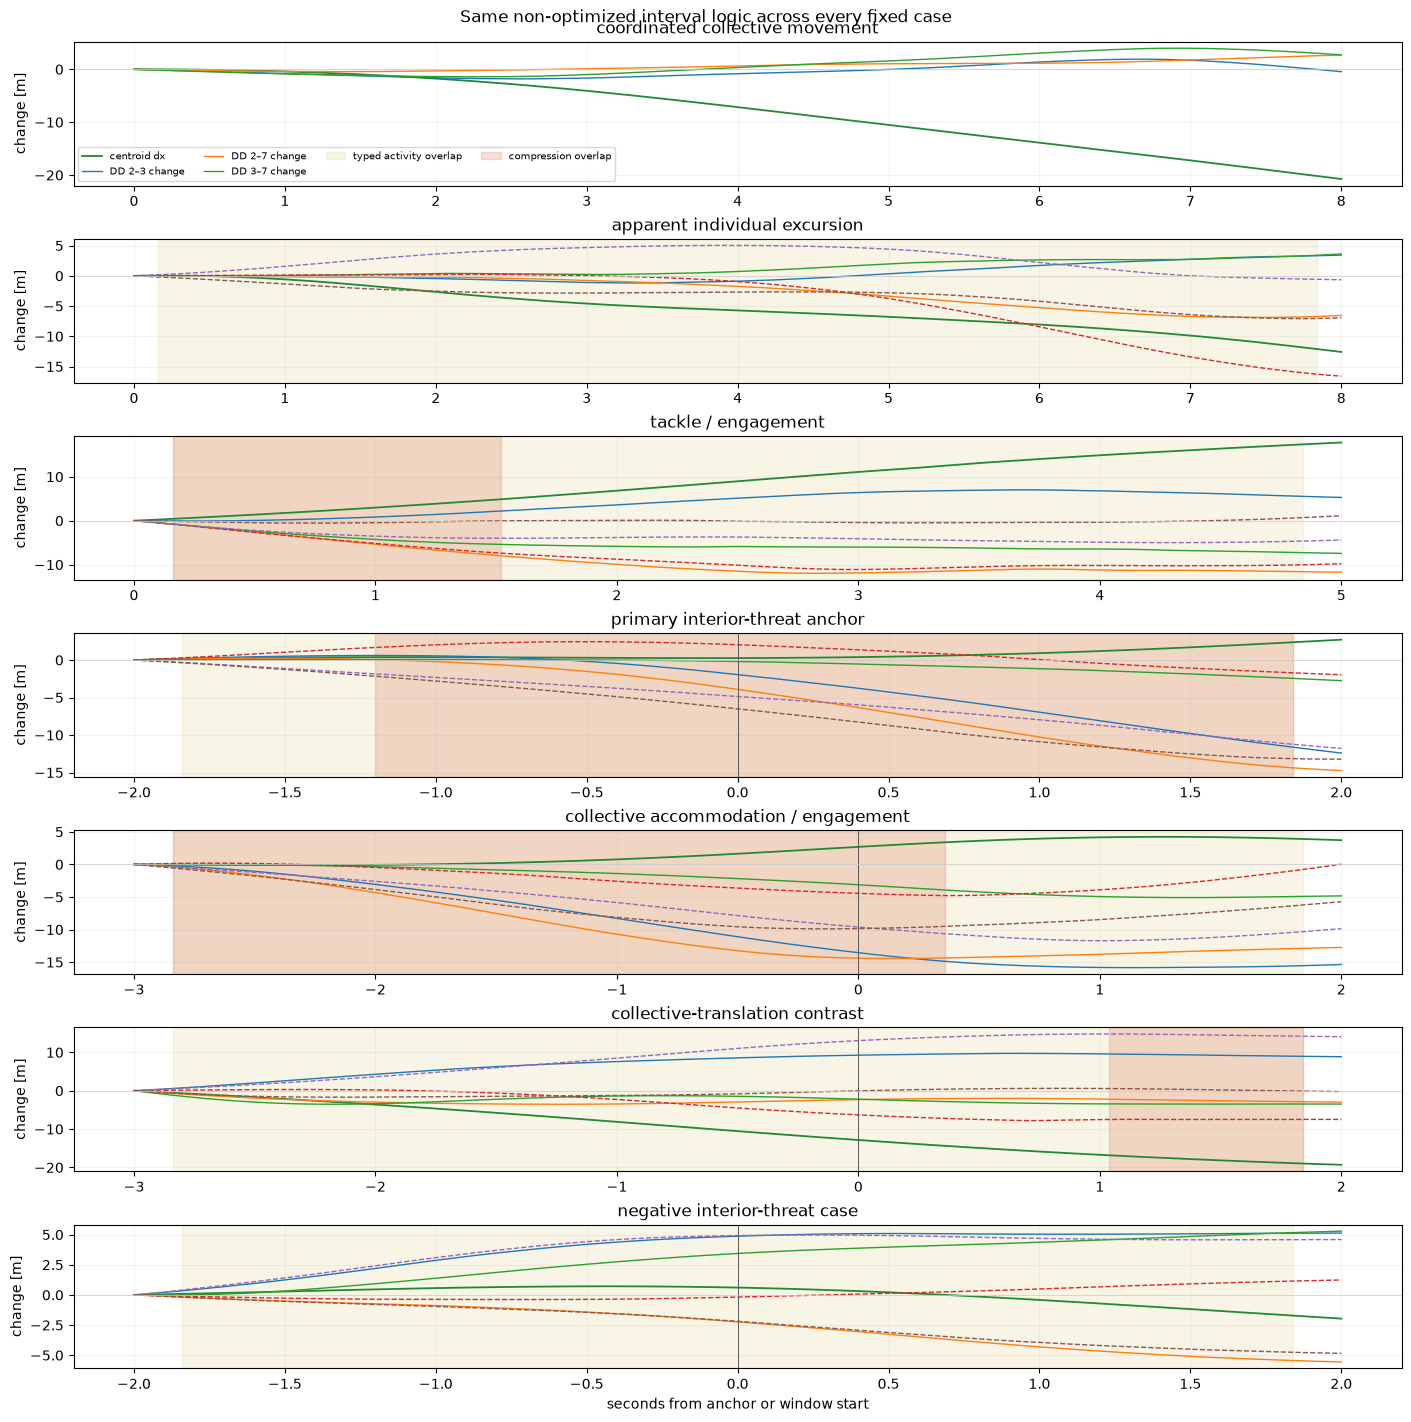

In [10]:
fig,axes=plt.subplots(len(CASES),1,figsize=(14,14),constrained_layout=True)
for ax,case in zip(axes,CASES):
    w,levels,rates,activity,compression=candidate_masks(case,7); ref=case.get('anchor') if case.get('anchor') is not None else case['start']; t=w['Time [s]']-ref
    ax.plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],c='#228833',lw=1.3,label='centroid dx')
    for name,v in levels['dd'].items(): ax.plot(t,v-v.iloc[0],lw=1,label=f'DD {name} change')
    for name,v in levels['do'].items(): ax.plot(t,v-v.iloc[0],lw=1,ls='--',label=f'DO {name} change')
    ax.fill_between(t,0,1,where=activity,transform=ax.get_xaxis_transform(),color='#ddcc77',alpha=.18,label='typed activity overlap')
    ax.fill_between(t,0,1,where=compression,transform=ax.get_xaxis_transform(),color='#cc3311',alpha=.16,label='compression overlap')
    if case.get('anchor') is not None: ax.axvline(0,c='0.35',lw=.7)
    ax.axhline(0,c='0.8',lw=.5); ax.set(title=case['name'],ylabel='change [m]'); ax.grid(alpha=.15)
axes[-1].set_xlabel('seconds from anchor or window start'); axes[0].legend(fontsize=7,ncol=4)
fig.suptitle('Same non-optimized interval logic across every fixed case',y=1.005); plt.show()

## Cross-case findings and falsification

- **Coordinated translation:** no defender–opponent pair was fixed in the source diagnostic, so the overlap logic correctly remains unevaluable rather than manufacturing a relationship. Raw internal geometry changes enough to show that translation is coherent only comparatively, not rigid.
- **Apparent excursion:** direction-agnostic typed activity produces broad overlap because focal, local, and opponent relationships are continuously moving. The interior-compression lens is absent or brief and does not capture the focal nature reliably. This exposes the narrowness of compression logic.
- **Tackle/engagement:** persistent contraction across several local and opponent relationships creates a candidate interval, but the pitch view contains collective translation, ball response, and tackle mechanics. The logic cannot turn the interval into a clean relational sequence.
- **1230.12s and 1232.28s:** both contain sustained multi-defender/multi-opponent contraction. The later accommodation window shows contraction followed by expansion; episode edges depend on which part of the same continuous play is windowed.
- **Collective-translation contrast:** direction-agnostic activity overlap is common; the compression lens is more limited. Large centroid movement remains an explicit competing description.
- **4197.04s negative case:** the fixed compression-overlap logic remains absent because selected defender-pair and threat-distance directions are mixed. This result was obtained without retuning the persistence or overlap choices.

Falsification results:

- **Does activity overcall?** Yes. Direction-agnostic persistent overlap appears across much of active play once several relationships are inspected. It is not sufficient for episode-ness.
- **Are boundaries smoothing-sensitive?** Moderately. The 5/7/9-frame versions preserve broad intervals but shift short edges and may add/remove brief fragments. Boundaries are not stable enough to be treated as detected event times.
- **Are episodes mostly ball/collective movement?** Sometimes. Tackle and translation cases retain strong shared-motion alternatives, and ball-relative changes are often large.
- **Can 4197.04s remain negative without hand-tuning?** Yes for the specific interior-compression lens, because its relationship directions remain heterogeneous.
- **Can intervals be defended from raw pitch geometry?** The 1230.12s compression interval can; several broader activity intervals cannot.
- **Is interpretation still case-specific?** Yes. A rule useful for interior convergence does not adequately describe focal excursion, rotation, handoff-like change, or every accommodation pattern.

## Conclusion: B — partially feasible

Simple non-optimized interval logic can expose a plausible interior-compression reconfiguration interval in the strongest fixed case and preserve the negative case, but “episode-ness” is not yet generally operationalizable. Direction-agnostic activity overcalls; compression logic is context-specific; boundaries move under fixed smoothing sensitivity; and shared ball/collective motion remains difficult to separate without interpretation.

**Defensive relational reallocation** can provisionally include a bounded interval in which a soccer-interpretable pattern of typed relationships changes persistently and jointly. It cannot yet mean any multi-channel activity, a universal detected event, a scalar magnitude, or a tactical state. A future operational definition would need pre-specified relation selection and pattern-specific validation without collapsing channels.

No composite score, summed magnitude, weights, reallocation index, gravity/style metric, structure/exposure score, assignment inference, state classifier, automated change point, optimized threshold, clustering, network, HMM, ML, causal inference, or dataset expansion is introduced. Phase 2C stops here.